In [ ]:
# =============================================================================
# Projeto de Inteligência Artificial - 7ºJ SI Noite
# Predição de Hospitalização em Casos Confirmados de Dengue (SP)
#
# Integrantes do grupo:
#   - Geovanna da Silva Lima - RA: 10420059#   - Pedro Henrique Mansano Fernandes - RA: 10388037
#   - Priscila Raquel Herculano Correia - RA: 10420400#
# Síntese do conteúdo do arquivo:
#   Notebook de Análise Exploratória e Preparação dos Dados para o
#   problema de predição de hospitalização em pacientes com dengue
#   confirmada, utilizando dados públicos do SINAN/DATASUS (UF: SP).
# Histórico de alterações:
#   | Data       | Autor                    | Descrição                                     |
#   |------------|--------------------------|-----------------------------------------------|
#   | 2026-09-10 | Pedro Henrique           | Criação inicial do notebook                   |
#   | 2026-09-13 | Geovanna da Silva Lima   | Ajuste do GitHub e doumentação                |
# ==========================================================================================|

# Predição de Hospitalização em Casos Confirmados de Dengue

## Apresentação do problema

A dengue é uma arbovirose de grande relevância para a saúde pública brasileira, com
picos sazonais que sobrecarregam unidades de saúde. Neste projeto, utilizamos dados
reais e públicos do **SINAN (Sistema de Informação de Agravos de Notificação)**,
disponibilizados pelo DATASUS, referentes a notificações de dengue no estado de
São Paulo em 2025.

**Objetivo:** construir um modelo de classificação capaz de prever, **a partir de
informações disponíveis apenas no primeiro atendimento** (sintomas, sinais clínicos,
comorbidades e dados demográficos), se um paciente com dengue confirmada será
**hospitalizado ou não**. A variável-alvo é `HOSPITALIZ` (1 = Sim, 2 = Não).

**Por que hospitalização, e não óbito?** Uma análise preliminar mostrou que o óbito
pelo agravo é um evento extremamente raro na base (~0,13% dos casos confirmados em
SP), o que inviabiliza a construção de um modelo robusto dentro do escopo de um
projeto semestral. A hospitalização, embora também desbalanceada (~5% dos casos),
oferece uma quantidade de exemplos positivos suficiente para um aprendizado
significativo, além de ter relevância prática direta (apoio à triagem e à gestão de
leitos).

**Escopo:** dados de notificação do estado de São Paulo (UF de notificação = SP),
ano de 2025, restritos a casos com classificação final confirmada
(`CLASSI_FIN` ∈ {10, 11, 12} — Dengue, Dengue com sinais de alarme, Dengue grave).

> ⚠️ **Nota sobre o dicionário de dados:** o dicionário oficial de campos do SINAN
> descreve `CLASSI_FIN` com a codificação antiga (1 = Confirmado, 2 = Descartado).
> Os dados de 2025 já utilizam a codificação vigente mais recente
> (10 = Dengue, 11 = Dengue com sinais de alarme, 12 = Dengue grave, 8 = Inconclusivo).
> Este notebook usa a codificação **vigente**, validada diretamente no arquivo CSV.

**Aspectos éticos:** por se tratar de dados de saúde, ainda que públicos e sem
identificação direta do paciente, o uso é feito de forma agregada e exclusivamente
para fins acadêmicos. Variáveis sensíveis (raça/cor, sexo, gestação) são mantidas
para fins de análise de equidade do modelo, mas seu uso em produção exigiria
avaliação cuidadosa de viés — discussão retomada na seção de Ética do relatório.


## 1. Configuração do ambiente

In [96]:
# Bibliotecas utilizadas: pandas/numpy para manipulação de dados,
# matplotlib/seaborn para visualização, scikit-learn para o split treino/teste.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

pd.set_option("display.max_columns", 100)


In [97]:
# >>> PREENCHER AQUI: caminhos dos arquivos <<<
CSV_PATH = "./data/DENGBR25.csv"          # CSV oficial do SINAN (2025)
DICT_PATH = "coloque_aqui_o_caminho/dic_dados_dengue.pdf"  # Dicionário de dados (referência)

# Parâmetros do recorte de escopo
UF_NOTIFICACAO = "35"          # 35 = São Paulo (código IBGE)
CLASSI_FIN_CONFIRMADOS = ["10", "11", "12"]  # Dengue / c/ sinais de alarme / grave
TAMANHO_AMOSTRA = 40000        # tamanho da amostra estratificada final
SEED = 42                      # semente para reprodutibilidade


## 2. Carregamento e filtragem inicial

O arquivo original tem ~1,6 milhão de linhas e 121 colunas (~450 MB), o que pode
estourar a memória disponível se lido de uma vez. Por isso:

1. Lemos o CSV em **chunks** (pedaços), selecionando apenas as colunas relevantes.
2. Aplicamos o filtro de escopo (UF = SP, casos confirmados) **durante** a leitura,
   para já reduzir o volume de dados mantido em memória.


In [98]:
# Colunas mantidas: identificação do recorte + variável-alvo + variáveis
# disponíveis no primeiro atendimento (demografia, sintomas, comorbidades).
# Colunas como DT_INTERNA, DT_OBITO, DT_ENCERRA, EVOLUCAO são propositalmente
# EXCLUÍDAS por só existirem/serem preenchidas após o desfecho (vazamento de dados).
COLUNAS_USADAS = [
    # Escopo / filtro
    "SG_UF_NOT", "CLASSI_FIN",
    # Alvo
    "HOSPITALIZ",
    # Demografia
    "NU_IDADE_N", "CS_SEXO", "CS_GESTANT", "CS_RACA", "CS_ESCOL_N",
    # Sinais clínicos (primeiro atendimento)
    "FEBRE", "MIALGIA", "CEFALEIA", "EXANTEMA", "VOMITO", "NAUSEA",
    "DOR_COSTAS", "CONJUNTVIT", "ARTRITE", "ARTRALGIA", "PETEQUIA_N",
    "LEUCOPENIA", "LACO", "DOR_RETRO",
    # Comorbidades pré-existentes
    "DIABETES", "HEMATOLOG", "HEPATOPAT", "RENAL", "HIPERTENSA",
    "ACIDO_PEPT", "AUTO_IMUNE",
]

chunks_filtrados = []
for chunk in pd.read_csv(CSV_PATH, usecols=COLUNAS_USADAS, dtype=str,
                          chunksize=200_000, low_memory=False):
    mask = (chunk["SG_UF_NOT"] == UF_NOTIFICACAO) & \
           (chunk["CLASSI_FIN"].isin(CLASSI_FIN_CONFIRMADOS))
    chunks_filtrados.append(chunk[mask])

df = pd.concat(chunks_filtrados, ignore_index=True)
print(f"Linhas após filtro (SP, casos confirmados): {len(df):,}")
df.head()


Linhas após filtro (SP, casos confirmados): 886,244


,SG_UF_NOT,NU_IDADE_N,CS_SEXO,CS_GESTANT,CS_RACA,CS_ESCOL_N,FEBRE,MIALGIA,CEFALEIA,EXANTEMA,VOMITO,NAUSEA,DOR_COSTAS,CONJUNTVIT,ARTRITE,ARTRALGIA,PETEQUIA_N,LEUCOPENIA,LACO,DOR_RETRO,DIABETES,HEMATOLOG,HEPATOPAT,RENAL,HIPERTENSA,ACIDO_PEPT,AUTO_IMUNE,HOSPITALIZ,CLASSI_FIN
0,35,4011,M,6,1,9,1,1,2,2,1,1,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,10
1,35,4034,F,5,1,9,2,1,1,2,2,1,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,10
2,35,4005,F,6,4,10,1,1,2,2,1,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,10
3,35,4090,M,6,4,6,2,1,2,2,1,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,1,10
4,35,4020,M,6,1,NaN,1,1,1,2,2,2,2,2,2,1,2,2,2,2,2,2,2,2,2,2,2,2,10


## 3. Visão geral do dataset filtrado

In [99]:
# Estrutura geral: tipos de dado, contagem de nulos por coluna
print(df.shape)
df.info()


(886244, 29)
<class 'pandas.DataFrame'>
RangeIndex: 886244 entries, 0 to 886243
Data columns (total 29 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   SG_UF_NOT   886244 non-null  str  
 1   NU_IDADE_N  886244 non-null  str  
 2   CS_SEXO     886244 non-null  str  
 3   CS_GESTANT  886159 non-null  str  
 4   CS_RACA     886243 non-null  str  
 5   CS_ESCOL_N  704272 non-null  str  
 6   FEBRE       886243 non-null  str  
 7   MIALGIA     886243 non-null  str  
 8   CEFALEIA    886243 non-null  str  
 9   EXANTEMA    886243 non-null  str  
 10  VOMITO      886243 non-null  str  
 11  NAUSEA      886243 non-null  str  
 12  DOR_COSTAS  886243 non-null  str  
 13  CONJUNTVIT  886243 non-null  str  
 14  ARTRITE     886243 non-null  str  
 15  ARTRALGIA   886243 non-null  str  
 16  PETEQUIA_N  886243 non-null  str  
 17  LEUCOPENIA  886243 non-null  str  
 18  LACO        886243 non-null  str  
 19  DOR_RETRO   886243 non-null  str  
 20  DI

In [100]:
# Percentual de valores nulos (NaN) por coluna
(df.isna().mean() * 100).sort_values(ascending=False).round(2)


CS_ESCOL_N    20.53
HOSPITALIZ    15.90
CS_GESTANT     0.01
FEBRE          0.00
CS_RACA        0.00
EXANTEMA       0.00
VOMITO         0.00
NAUSEA         0.00
CEFALEIA       0.00
DOR_COSTAS     0.00
ARTRALGIA      0.00
CONJUNTVIT     0.00
MIALGIA        0.00
DIABETES       0.00
HEMATOLOG      0.00
RENAL          0.00
ARTRITE        0.00
LEUCOPENIA     0.00
LACO           0.00
DOR_RETRO      0.00
PETEQUIA_N     0.00
HIPERTENSA     0.00
ACIDO_PEPT     0.00
AUTO_IMUNE     0.00
HEPATOPAT      0.00
CS_SEXO        0.00
SG_UF_NOT      0.00
NU_IDADE_N     0.00
CLASSI_FIN     0.00
dtype: float64

## 4. Tratamento da variável-alvo (`HOSPITALIZ`)

Conforme o dicionário de dados: `1 = Sim`, `2 = Não`, `9 = Ignorado`. Registros com
valor ignorado ou ausente não têm informação de desfecho e por isso são descartados
— não faz sentido imputar a variável que queremos prever.


In [101]:
print("Distribuição bruta de HOSPITALIZ:")
print(df["HOSPITALIZ"].value_counts(dropna=False))

# Mantém apenas registros com desfecho conhecido (1=Sim, 2=Não)
df = df[df["HOSPITALIZ"].isin(["1", "2"])].copy()

# Recodifica para formato binário (1 = hospitalizado, 0 = não hospitalizado)
df["HOSPITALIZ"] = df["HOSPITALIZ"].map({"1": 1, "2": 0})

print(f"\nLinhas após remover ignorados/ausentes: {len(df):,}")
print("\nBalanceamento da classe-alvo:")
print(df["HOSPITALIZ"].value_counts(normalize=True).round(4) * 100)


Distribuição bruta de HOSPITALIZ:
HOSPITALIZ
2      699116
NaN    140878
1       34517
9       11733
Name: count, dtype: int64

Linhas após remover ignorados/ausentes: 733,633

Balanceamento da classe-alvo:
HOSPITALIZ
0    95.3
1     4.7
Name: proportion, dtype: float64


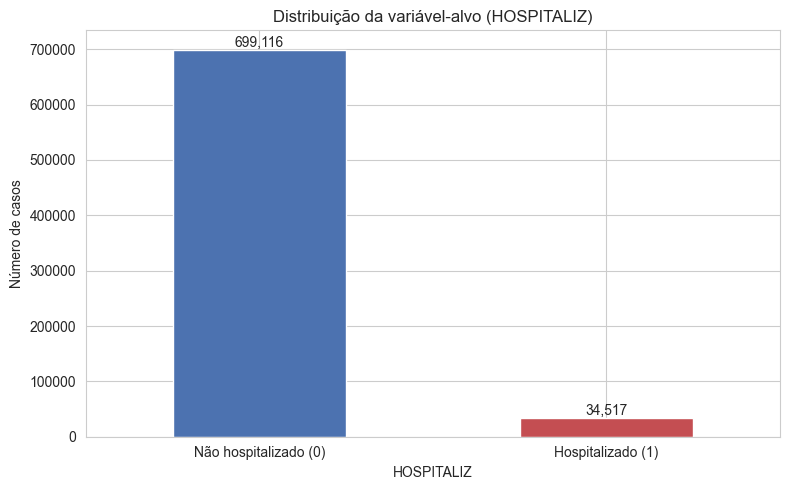

In [102]:
# Visualização do desbalanceamento de classes
ax = df["HOSPITALIZ"].value_counts().sort_index().plot(kind="bar", color=["#4C72B0", "#C44E52"])
ax.set_xticklabels(["Não hospitalizado (0)", "Hospitalizado (1)"], rotation=0)
ax.set_ylabel("Número de casos")
ax.set_title("Distribuição da variável-alvo (HOSPITALIZ)")
for i, v in enumerate(df["HOSPITALIZ"].value_counts().sort_index()):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()


## 5. Análise exploratória dos dados (EDA)

### 5.1 Perfil demográfico

Idades implausíveis (>110 anos) tratadas como nulo: 23
count    733610.000000
mean         37.945275
std          20.062776
min           0.000000
25%          22.000000
50%          37.000000
75%          52.000000
max         110.000000
Name: IDADE_ANOS, dtype: float64


C:\Users\pedro\AppData\Local\Temp\ipykernel_28728\3047856930.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Não hospitalizado", "Hospitalizado"])


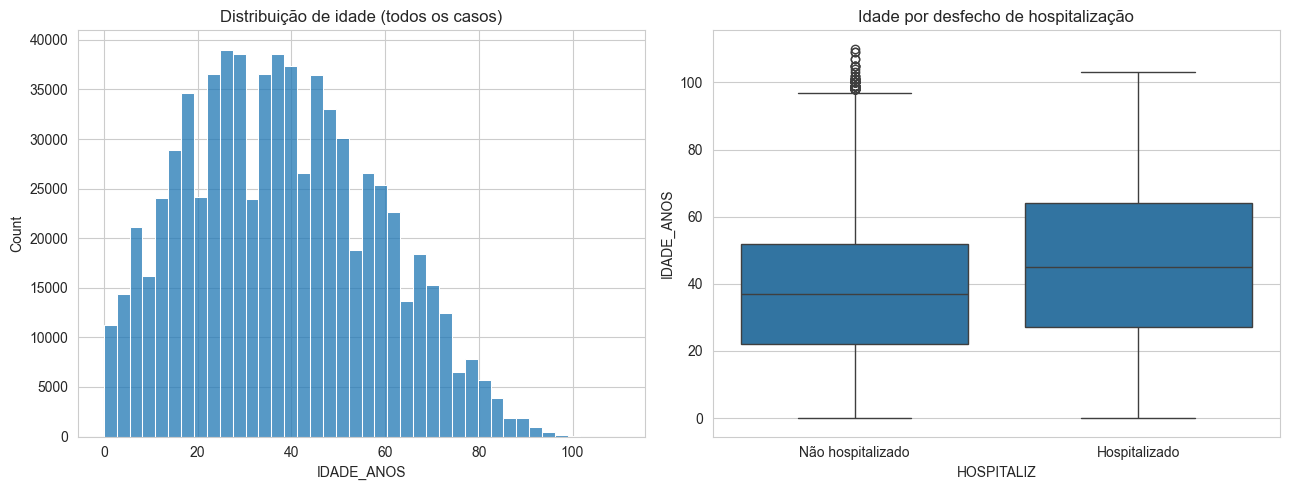

In [103]:
# NU_IDADE_N usa uma codificação especial do SINAN: o primeiro dígito indica a
# unidade (1=hora, 2=dia, 3=mês, 4=ano) e os dígitos seguintes o valor.
# Convertendo para idade aproximada em anos (registros em hora/dia/mês => bebês).
def decodifica_idade(valor):
    try:
        v = str(int(float(valor))).zfill(4)
    except (ValueError, TypeError):
        return np.nan
    unidade, numero = v[0], int(v[1:])
    if unidade == "4":       # anos
        return numero
    elif unidade == "3":     # meses
        return numero / 12
    elif unidade in ("1", "2"):  # horas ou dias
        return 0
    return np.nan

df["IDADE_ANOS"] = df["NU_IDADE_N"].apply(decodifica_idade)

# Saneamento: o SINAN é alimentado manualmente e contém erros de digitação
# (ex.: idades acima de 110 anos). Valores implausíveis viram nulo.
n_invalidas = (df["IDADE_ANOS"] > 110).sum()
print(f"Idades implausíveis (>110 anos) tratadas como nulo: {n_invalidas}")
df.loc[df["IDADE_ANOS"] > 110, "IDADE_ANOS"] = np.nan

print(df["IDADE_ANOS"].describe())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(df["IDADE_ANOS"], bins=40, ax=axes[0])
axes[0].set_title("Distribuição de idade (todos os casos)")

sns.boxplot(data=df, x="HOSPITALIZ", y="IDADE_ANOS", ax=axes[1])
axes[1].set_xticklabels(["Não hospitalizado", "Hospitalizado"])
axes[1].set_title("Idade por desfecho de hospitalização")
plt.tight_layout()
plt.show()


HOSPITALIZ      0     1
CS_SEXO                
F           95.34  4.66
I           95.25  4.75
M           95.25  4.75


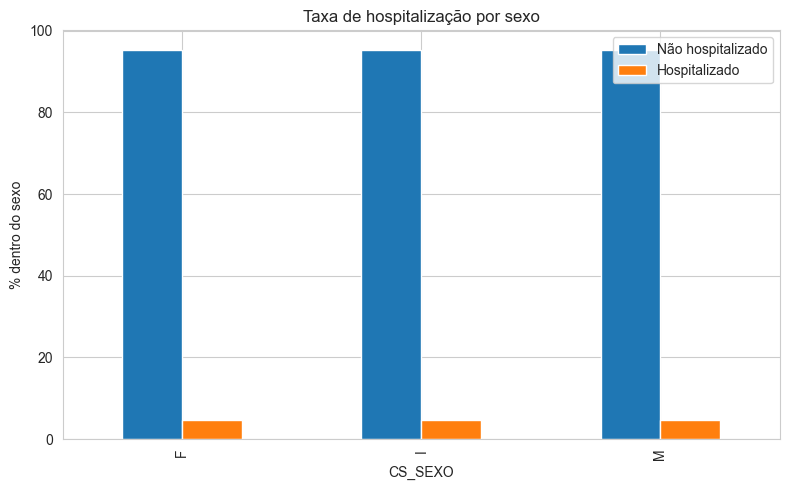

In [104]:
# Sexo e desfecho
tab_sexo = pd.crosstab(df["CS_SEXO"], df["HOSPITALIZ"], normalize="index") * 100
print(tab_sexo.round(2))

tab_sexo.plot(kind="bar", stacked=False)
plt.ylabel("% dentro do sexo")
plt.title("Taxa de hospitalização por sexo")
plt.legend(["Não hospitalizado", "Hospitalizado"])
plt.tight_layout()
plt.show()


### 5.2 Sinais clínicos e comorbidades vs. hospitalização

In [105]:
# Para cada sinal clínico/comorbidade (codificado 1=Sim, 2=Não), calcula a
# proporção de "Sim" entre hospitalizados vs não hospitalizados.
sinais_clinicos = ["FEBRE", "MIALGIA", "CEFALEIA", "EXANTEMA", "VOMITO", "NAUSEA",
                   "DOR_COSTAS", "CONJUNTVIT", "ARTRITE", "ARTRALGIA", "PETEQUIA_N",
                   "LEUCOPENIA", "LACO", "DOR_RETRO"]
comorbidades = ["DIABETES", "HEMATOLOG", "HEPATOPAT", "RENAL", "HIPERTENSA",
                "ACIDO_PEPT", "AUTO_IMUNE"]

def taxa_positiva_por_desfecho(coluna):
    tmp = df[[coluna, "HOSPITALIZ"]].copy()
    tmp["positivo"] = (tmp[coluna] == "1").astype(int)
    return tmp.groupby("HOSPITALIZ")["positivo"].mean() * 100

resumo_sinais = pd.DataFrame({c: taxa_positiva_por_desfecho(c) for c in sinais_clinicos}).T
resumo_sinais.columns = ["% Não hospitalizado", "% Hospitalizado"]
resumo_sinais.sort_values("% Hospitalizado", ascending=False)


,% Não hospitalizado,% Hospitalizado
FEBRE,85.842693,81.223745
MIALGIA,81.470028,75.380247
CEFALEIA,81.478753,66.761306
NAUSEA,44.705600,47.037692
VOMITO,25.477889,34.041197
DOR_RETRO,32.802854,20.526118
DOR_COSTAS,29.799204,19.969870
LEUCOPENIA,4.372093,14.639163
ARTRALGIA,15.466961,13.648347
EXANTEMA,7.448978,7.941015


In [106]:
resumo_comorb = pd.DataFrame({c: taxa_positiva_por_desfecho(c) for c in comorbidades}).T
resumo_comorb.columns = ["% Não hospitalizado", "% Hospitalizado"]
resumo_comorb.sort_values("% Hospitalizado", ascending=False)


,% Não hospitalizado,% Hospitalizado
HIPERTENSA,11.037796,22.893067
DIABETES,5.280526,12.596691
RENAL,0.453287,1.781731
AUTO_IMUNE,0.694448,1.648463
HEMATOLOG,0.483897,1.370339
HEPATOPAT,0.430544,0.996610
ACIDO_PEPT,0.410375,0.460643


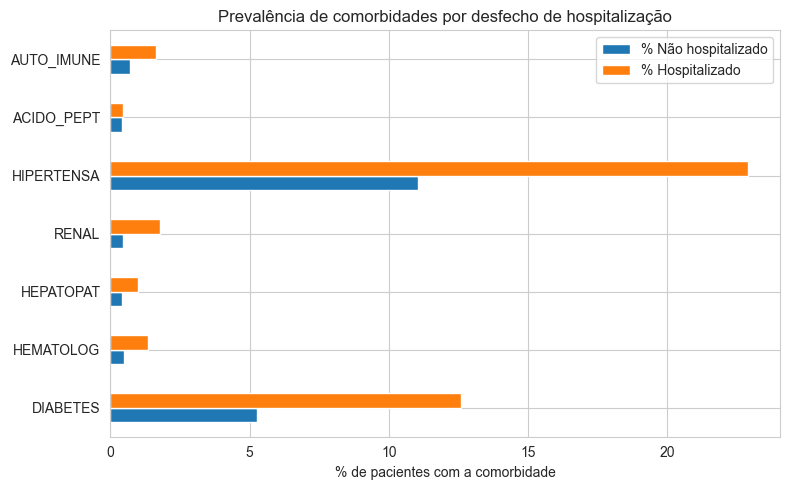

In [107]:
resumo_comorb.plot(kind="barh", figsize=(8, 5))
plt.xlabel("% de pacientes com a comorbidade")
plt.title("Prevalência de comorbidades por desfecho de hospitalização")
plt.tight_layout()
plt.show()


### 5.3 Valores ignorados em variáveis sensíveis

In [108]:
# CS_GESTANT e CS_RACA têm parcela relevante de "Ignorado" (código 9),
# diferente das variáveis clínicas obrigatórias (que praticamente não têm buraco).
for col in ["CS_GESTANT", "CS_RACA", "CS_ESCOL_N"]:
    pct_ignorado = (df[col] == "9").mean() * 100
    pct_nulo = df[col].isna().mean() * 100
    print(f"{col}: {pct_ignorado:.1f}% ignorado | {pct_nulo:.1f}% nulo")


CS_GESTANT: 6.5% ignorado | 0.0% nulo
CS_RACA: 13.7% ignorado | 0.0% nulo
CS_ESCOL_N: 28.5% ignorado | 18.3% nulo


## 6. Preparação dos dados

Passos aplicados:
1. Recodificação das variáveis binárias (`1`/`2` → `1`/`0`).
2. Tratamento de valores ignorados (`9`) em `CS_GESTANT` e `CS_RACA` como
   categoria própria (não removemos linhas, pois a informação clínica principal
   permanece válida).
3. Remoção de colunas auxiliares que não entram no modelo (`SG_UF_NOT`,
   `CLASSI_FIN`, `NU_IDADE_N` bruto).
4. Amostragem estratificada para reduzir o volume de dados a um tamanho
   confortável para experimentação, mantendo a proporção original das classes.


In [109]:
# 6.1 Recodifica sinais clínicos e comorbidades: 1=Sim -> 1, 2=Não -> 0
binarias = sinais_clinicos + comorbidades
for col in binarias:
    df[col] = df[col].map({"1": 1, "2": 0})

# 6.2 Sexo: M/F -> categórico (mantido como string para one-hot posterior)
df["CS_SEXO"] = df["CS_SEXO"].replace({"I": np.nan})

# 6.3 Gestante, Raça e Escolaridade: valor ausente/ignorado tratado como
# categoria própria em vez de descartar a linha (evita perder ~28% dos dados
# por causa de uma única coluna secundária, como visto na seção 5.3)
df["CS_GESTANT"] = df["CS_GESTANT"].fillna("9")
df["CS_RACA"] = df["CS_RACA"].fillna("9")
df["CS_ESCOL_N"] = df["CS_ESCOL_N"].fillna("99")

# 6.4 Remove colunas que não farão parte do modelo
df_prep = df.drop(columns=["SG_UF_NOT", "CLASSI_FIN", "NU_IDADE_N"])

print(f"Formato final antes da amostragem: {df_prep.shape}")
df_prep.head()


Formato final antes da amostragem: (733633, 27)


,CS_SEXO,CS_GESTANT,CS_RACA,CS_ESCOL_N,FEBRE,MIALGIA,CEFALEIA,EXANTEMA,VOMITO,NAUSEA,DOR_COSTAS,CONJUNTVIT,ARTRITE,ARTRALGIA,PETEQUIA_N,LEUCOPENIA,LACO,DOR_RETRO,DIABETES,HEMATOLOG,HEPATOPAT,RENAL,HIPERTENSA,ACIDO_PEPT,AUTO_IMUNE,HOSPITALIZ,IDADE_ANOS
0,M,6,1,9,1,1,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,11.0
1,F,5,1,9,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,34.0
2,F,6,4,10,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5.0
3,M,6,4,6,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,90.0
4,M,6,1,99,1,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,20.0


In [110]:
# Checagem final de nulos remanescentes antes de amostrar
(df_prep.isna().mean() * 100).sort_values(ascending=False).round(2)


CS_SEXO       0.05
IDADE_ANOS    0.00
CS_GESTANT    0.00
CS_ESCOL_N    0.00
FEBRE         0.00
MIALGIA       0.00
CEFALEIA      0.00
EXANTEMA      0.00
VOMITO        0.00
NAUSEA        0.00
CS_RACA       0.00
DOR_COSTAS    0.00
CONJUNTVIT    0.00
ARTRALGIA     0.00
ARTRITE       0.00
LEUCOPENIA    0.00
LACO          0.00
DOR_RETRO     0.00
PETEQUIA_N    0.00
DIABETES      0.00
HEMATOLOG     0.00
RENAL         0.00
HEPATOPAT     0.00
HIPERTENSA    0.00
ACIDO_PEPT    0.00
AUTO_IMUNE    0.00
HOSPITALIZ    0.00
dtype: float64

In [111]:
# Remove eventuais linhas com nulos residuais (ex.: idade não decodificável, sexo ignorado)
antes = len(df_prep)
df_prep = df_prep.dropna()
print(f"Linhas removidas por nulos residuais: {antes - len(df_prep):,} ({(antes - len(df_prep)) / antes * 100:.2f}%)")
print(f"Linhas restantes: {len(df_prep):,}")


Linhas removidas por nulos residuais: 381 (0.05%)
Linhas restantes: 733,252


### 6.1 Amostragem estratificada

In [112]:
# Reduz o dataset a TAMANHO_AMOSTRA linhas, preservando a proporção original
# entre hospitalizados e não hospitalizados (amostragem estratificada).
if len(df_prep) > TAMANHO_AMOSTRA:
    df_amostra, _ = train_test_split(
        df_prep,
        train_size=TAMANHO_AMOSTRA,
        stratify=df_prep["HOSPITALIZ"],
        random_state=SEED,
    )
else:
    df_amostra = df_prep.copy()

print(f"Tamanho da amostra final: {len(df_amostra):,}")
print("\nBalanceamento preservado na amostra:")
print(df_amostra["HOSPITALIZ"].value_counts(normalize=True).round(4) * 100)


Tamanho da amostra final: 40,000

Balanceamento preservado na amostra:
HOSPITALIZ
0    95.3
1     4.7
Name: proportion, dtype: float64


## 7. Divisão treino/teste

Split estratificado (80/20) para garantir que a proporção de hospitalizados seja
mantida tanto no treino quanto no teste — essencial em problemas desbalanceados,
para que o conjunto de teste seja representativo.


In [113]:
X = df_amostra.drop(columns=["HOSPITALIZ"])
y = df_amostra["HOSPITALIZ"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

print(f"Treino: {X_train.shape[0]:,} linhas | Teste: {X_test.shape[0]:,} linhas")
print(f"\n% positivos no treino: {y_train.mean() * 100:.2f}%")
print(f"% positivos no teste:  {y_test.mean() * 100:.2f}%")


Treino: 32,000 linhas | Teste: 8,000 linhas

% positivos no treino: 4.71%
% positivos no teste:  4.70%


## 8. Exportação dos dados preparados

Salva os conjuntos de treino e teste em CSV, para uso na etapa de modelagem
(Segundo Bimestre / N2).


In [114]:
X_train.assign(HOSPITALIZ=y_train).to_csv("dengue_sp_treino.csv", index=False)
X_test.assign(HOSPITALIZ=y_test).to_csv("dengue_sp_teste.csv", index=False)

print("Arquivos salvos: dengue_sp_treino.csv, dengue_sp_teste.csv")


Arquivos salvos: dengue_sp_treino.csv, dengue_sp_teste.csv


## 9. Próximos passos (N2)

- Codificação (one-hot / ordinal) das variáveis categóricas restantes.
- Treinamento de modelos de classificação (ex.: Regressão Logística, Random
  Forest) com `class_weight="balanced"` para lidar com o desbalanceamento.
- Avaliação com métricas adequadas a classes desbalanceadas: F1-score, recall,
  precisão e AUC-ROC (não apenas acurácia).
- Discussão de equidade do modelo entre subgrupos demográficos (sexo, raça/cor).
